<a href="https://colab.research.google.com/github/SanikaKalyani/mnist-digit-classification-ann/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training started...

Iteration 0 | Loss: 2.3022 | Accuracy: 8.95%
Iteration 50 | Loss: 0.8525 | Accuracy: 68.10%
Iteration 100 | Loss: 0.1793 | Accuracy: 95.10%
Iteration 150 | Loss: 0.0970 | Accuracy: 98.00%
Iteration 200 | Loss: 0.0569 | Accuracy: 99.40%
Iteration 250 | Loss: 0.0364 | Accuracy: 99.70%
Iteration 300 | Loss: 0.0252 | Accuracy: 99.80%
Iteration 350 | Loss: 0.0184 | Accuracy: 99.85%

Training completed!

Prediction: 7
Actual: 7


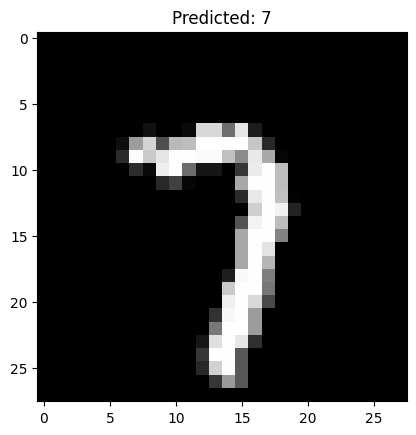

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist


(X_train, y_train), (X_test, y_test) = mnist.load_data()


X_train = X_train.reshape(X_train.shape[0], -1).T / 255.0
X_test = X_test.reshape(X_test.shape[0], -1).T / 255.0


def one_hot(y):
    one_hot_Y = np.zeros((10, y.size))
    one_hot_Y[y, np.arange(y.size)] = 1
    return one_hot_Y

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

X = X_train[:, :2000]
Y = Y_train[:, :2000]

#parameter initialization
input_size = 784
hidden_size = 128
output_size = 10

W1 = np.random.randn(hidden_size, input_size) * 0.01
b1 = np.zeros((hidden_size, 1))

W2 = np.random.randn(output_size, hidden_size) * 0.01
b2 = np.zeros((output_size, 1))

#activation frunction for hidden layer
def relu(Z):
    return np.maximum(0, Z)

#activation function for output layer
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

#forward processing
def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

#calculating loss
def compute_loss(A2, Y):
    m = Y.shape[1]
    loss = -np.sum(Y * np.log(A2 + 1e-8)) / m
    return loss

#backpropagation
def backward(X, Y, Z1, A1, A2, W2):
    m = X.shape[1]

    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2)
    dZ1[Z1 <= 0] = 0

    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


def update(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

#predicted output
def predict(A2):
    return np.argmax(A2, axis=0)

def accuracy(preds, labels):
    return np.mean(preds == labels) * 100

epochs = 400
lr = 1.1

print("Training started...\n")

for i in range(epochs):
    Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)

    loss = compute_loss(A2, Y)

    dW1, db1, dW2, db2 = backward(X, Y, Z1, A1, A2, W2)

    W1, b1, W2, b2 = update(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

    if i % 50 == 0:
        preds = predict(A2)
        acc = accuracy(preds, y_train[:2000])
        print(f"Iteration {i} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

print("\nTraining completed!")

index = 1321
sample = X_test[:, index].reshape(-1, 1)

_, _, _, A2 = forward(sample, W1, b1, W2, b2)
prediction = predict(A2)

print("\nPrediction:", prediction[0])
print("Actual:", y_test[index])

plt.imshow(X_test[:, index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {prediction[0]}")
plt.show()